In [47]:
from ucimlrepo import fetch_ucirepo 
  
iris = fetch_ucirepo(id=53) 
  
features = iris.data.features 
targets = iris.data.targets 

In [48]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

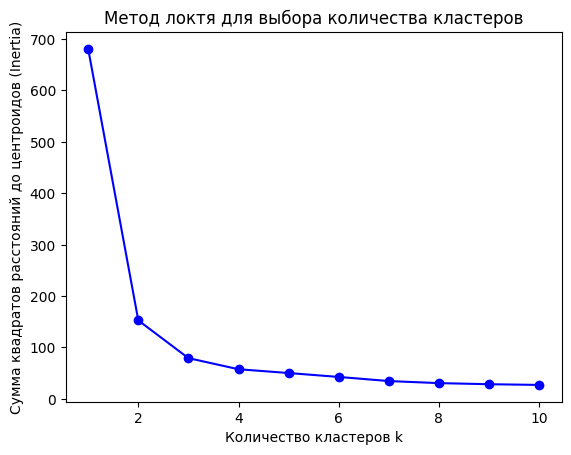

In [49]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний до центроидов (Inertia)')
plt.title('Метод локтя для выбора количества кластеров')
plt.show()

In [60]:
def plotClusters(cluster_type, values, title, ix):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, ix)
    plt.scatter(values[:, 0], values[:, 1], c=cluster_type, cmap='viridis')
    plt.title(title)

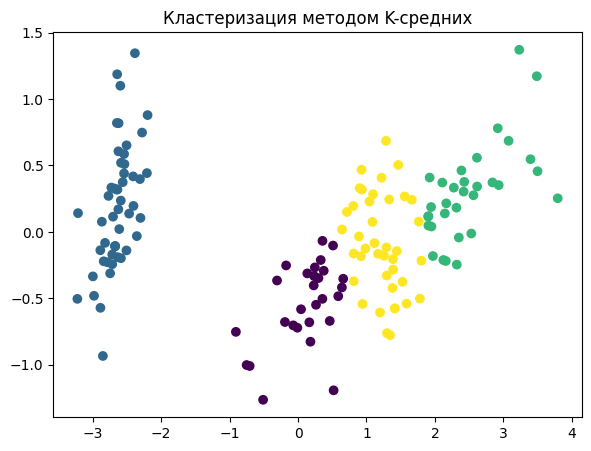

In [59]:
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=4, random_state=0)
clusters_kmeans = kmeans.fit_predict(features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)


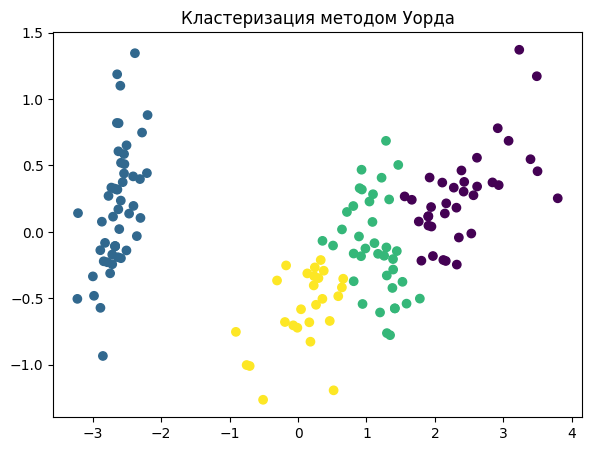

In [61]:
ward = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters_ward = ward.fit_predict(features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)
plotClusters(clusters_ward, X_pca, 'Кластеризация методом Уорда', 2)